# Section 20: CNN milestone projects

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import TensorDataset, DataLoader

from skimage.draw import line_aa

## Project 1: Import and classify CIFAR10

In [2]:
cifar10 = torchvision.datasets.CIFAR10(root='cifar10', download=True)

print(cifar10.data.shape)
print(cifar10.classes)
print(len(cifar10.targets))

(50000, 32, 32, 3)
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
50000


In [3]:
images = np.moveaxis(cifar10.data, -1, 1)
labels = cifar10.targets

images = images / np.max(images)

In [4]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

In [5]:
data_t = torch.tensor(images).float().to(device)
labels_t = torch.tensor(labels).long().to(device)

train_data, val_test_data, train_labels, val_test_labels = train_test_split(data_t, labels_t, test_size=.2)
val_data, test_data, val_labels, test_labels = train_test_split(val_test_data, val_test_labels, test_size=.5)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)
val_dataset = TensorDataset(val_data, val_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])

In [6]:
def create_model(print_toggle_param=False):
    class CifarNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.conv1 = nn.Conv2d(3, 32, 3, 1, 1)
            self.bnorm1 = nn.BatchNorm2d(32)

            self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
            self.bnorm2 = nn.BatchNorm2d(64)
     
            self.conv3 = nn.Conv2d(64, 128, 3, 1, 1)
            self.bnorm3 = nn.BatchNorm2d(128)
            
            self.fc1 = nn.Linear(2048, 256)
            self.dropout = nn.Dropout(.6)
            self.output = nn.Linear(256, 10)
            
        def forward(self, x_param):
            if print_toggle_param: print(f"Input: {x_param.shape}")

            x_local = self.bnorm1(self.conv1(x_param))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"First CPR block: {x_local.shape}")
            
            x_local = self.bnorm2(self.conv2(x_local))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"Second CPR block: {x_local.shape}")
            
            x_local = self.bnorm3(self.conv3(x_local))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"Third CPR block: {x_local.shape}")
            
            x_local = torch.flatten(x_local, start_dim=1)
            
            if print_toggle_param: print(f"Vectorized: {x_local.shape}")
            
            x_local = F.leaky_relu(self.fc1(x_local))
            x_local = self.dropout(x_local)
            x_local = self.output(x_local)
            
            if print_toggle_param: print(f"Final output: {x_local.shape}")
            
            return x_local
      
    cifar_net_local = CifarNet().to(device)
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.Adam(cifar_net_local.parameters(), lr=.001)
    
    return cifar_net_local, loss_function_local, optimizer_local

In [7]:
epochs_nr = 10

In [8]:
def train_model(cifar_net_local, loss_function_local, optimizer_local):
    train_losses_local = []
    test_losses_local = []
    train_accuracies_local = []
    val_accuracies_local = []
     
    for epoch in range(epochs_nr):
        batch_losses = []
        batch_accuracies = []
         
        cifar_net_local.train()
         
        for X_local, y_local in train_loader:
            y_pred_local = cifar_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
               
            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()
            
            batch_losses.append(loss_local.item())
            batch_accuracies.append(torch.mean((torch.argmax(y_pred_local, axis=1) == y_local).float()).item())

        train_losses_local.append(np.mean(batch_losses))
        train_accuracies_local.append(100 * np.mean(batch_accuracies))

        cifar_net_local.eval()
          
        X_local, y_local = next(iter(val_loader))
          
        with torch.no_grad():
            y_pred_local = cifar_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
          
        test_losses_local.append(loss_local.item())
        val_accuracies_local.append(100 * torch.mean((torch.argmax(y_pred_local, axis=1) == y_local).float()).item())
     
    return train_accuracies_local, val_accuracies_local, train_losses_local, test_losses_local, cifar_net_local

In [9]:
cifar_net, loss_function, optimizer = create_model()
train_accuracies, val_accuracies, train_losses, val_losses, cifar_net = train_model(cifar_net, loss_function, optimizer)

In [10]:
X, y = next(iter(test_loader))
y_pred = cifar_net(X)

test_loss = loss_function(y_pred, y).item()
test_accuracy = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float()).item()

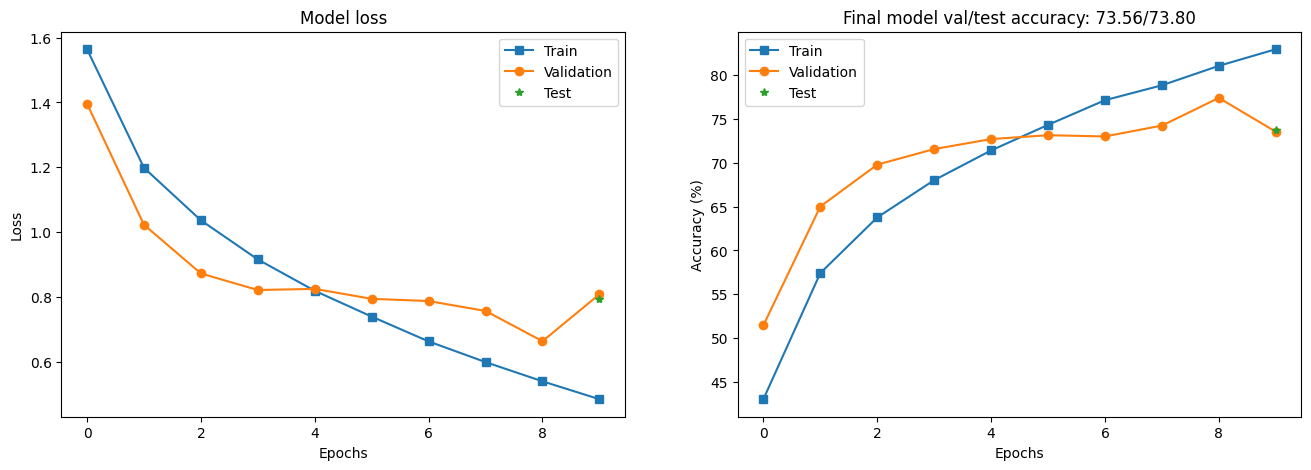

In [11]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses, 's-', label='Train')
ax[0].plot(val_losses, 'o-', label='Validation')
ax[0].plot(epochs_nr - 1, test_loss, '*', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(val_accuracies, 'o-', label='Validation')
ax[1].plot(epochs_nr - 1, test_accuracy, '*', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Final model val/test accuracy: %.2f/%.2f" %(val_accuracies[-1], test_accuracy))
ax[1].legend()

plt.show()

## Project 2: CIFAR-autoencoder

In [12]:
def create_model():
    class CifarNet(nn.Module):
        def __init__(self):
            super().__init__()

            self.enc = nn.Sequential(
                nn.Conv2d(3, 16, 4, 2, 1),
                nn.ReLU(),
                nn.Conv2d(16, 32, 4, 2, 1),
                nn.ReLU(),
                nn.Conv2d(32, 64, 4, 2, 1),
            )

            self.dec = nn.Sequential(
                nn.ConvTranspose2d(64, 32, 4, 2, 1),
                nn.ReLU(),
                nn.ConvTranspose2d(32, 16, 4, 2, 1),
                nn.ReLU(),
                nn.ConvTranspose2d(16, 3, 4, 2, 1),
            )

        def forward(self, x_param):
            return self.dec(self.enc(x_param))

    cifar_net_local = CifarNet().to(device)
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(cifar_net_local.parameters(), lr=.001)

    return cifar_net_local, loss_function_local, optimizer_local

In [13]:
train_data, test_data, train_labels, test_labels = train_test_split(data_t, labels_t, test_size=.1)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [14]:
def train_model(cifar_net_local, loss_function_local, optimizer_local):
    train_losses_local = []
    test_losses_local = []

    for epoch in range(epochs_nr):
        batch_losses = []

        cifar_net_local.train()

        for X_local, _ in train_loader:
            y_pred_local = cifar_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, X_local)

            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()

            batch_losses.append(loss_local.item())

        train_losses_local.append(np.mean(batch_losses))

        cifar_net_local.eval()

        X_local, _ = next(iter(test_loader))

        with torch.no_grad():
            y_pred_local = cifar_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, X_local)

        test_losses_local.append(loss_local.item())

    return train_losses_local, test_losses_local, cifar_net_local

In [15]:
cifar_net, loss_function, optimizer = create_model()
train_losses, test_losses, cifar_net = train_model(cifar_net, loss_function, optimizer)

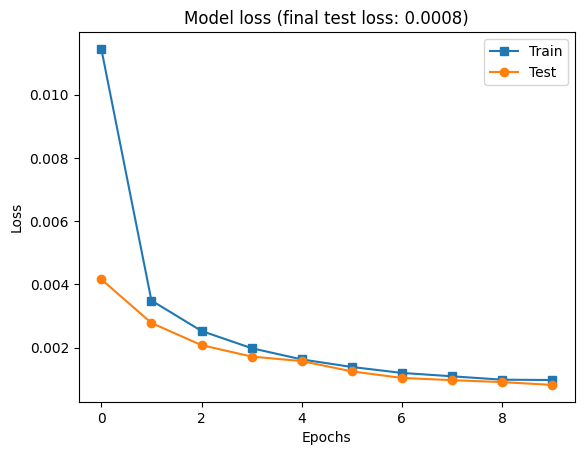

In [16]:
plt.plot(train_losses, 's-', label='Train')
plt.plot(test_losses, 'o-', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Model loss (final test loss: %.4f)" %test_losses[-1])
plt.legend()

plt.show()

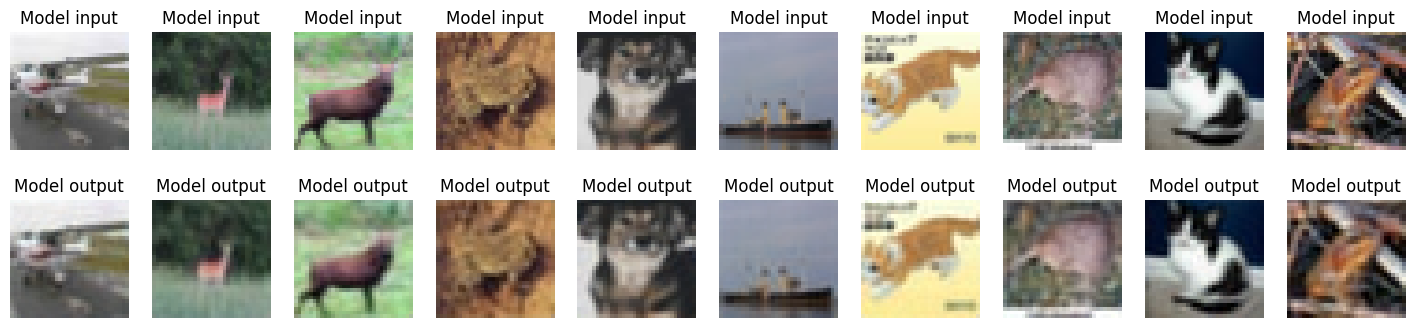

In [17]:
test_images = next(iter(test_loader))[0]
images_nr = test_images.shape[0]
image_indexes = np.random.choice(images_nr, size=32, replace=False)
X = test_images[image_indexes, :, :, :]
y_pred = cifar_net(X)

_, ax = plt.subplots(2, 10, figsize=(18, 4))

for i in range(10):
    selected_input = X[i].detach().cpu().permute(1, 2, 0)
    selected_output = y_pred[i].detach().cpu().permute(1, 2, 0).clamp(0, 1)

    ax[0, i].imshow(selected_input)
    ax[0, i].axis('off')
    ax[0, i].set_title("Model input")

    ax[1, i].imshow(selected_output)
    ax[1, i].axis('off')
    ax[1, i].set_title("Model output")

plt.show()

## Project 3: FMNIST

In [18]:
fmnist = torchvision.datasets.FashionMNIST(root='./fmnist', download=True)

print(fmnist.data.shape)
print(fmnist.classes)
print(len(fmnist.targets))

torch.Size([60000, 28, 28])
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
60000


In [19]:
images = np.expand_dims(fmnist.data, axis=1)
labels = fmnist.targets

images = images / np.max(images)

In [20]:
data_t = torch.tensor(images).float().to(device)
labels_t = labels.to(device)

train_data, val_test_data, train_labels, val_test_labels = train_test_split(data_t, labels_t, test_size=.2)
val_data, test_data, val_labels, test_labels = train_test_split(val_test_data, val_test_labels, test_size=.5)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)
val_dataset = TensorDataset(val_data, val_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])
val_loader = DataLoader(val_dataset, batch_size=val_dataset.tensors[0].shape[0])

In [21]:
def create_model(print_toggle_param=False):
    class FmnistNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.conv1 = nn.Conv2d(1, 28, 3, 1, 1)
            self.bnorm1 = nn.BatchNorm2d(28)

            self.conv2 = nn.Conv2d(28, 56, 3, 1, 1)
            self.bnorm2 = nn.BatchNorm2d(56)
     
            self.conv3 = nn.Conv2d(56, 112, 3, 1, 1)
            self.bnorm3 = nn.BatchNorm2d(112)
            
            self.fc1 = nn.Linear(1008, 256)
            self.dropout = nn.Dropout(.6)
            self.output = nn.Linear(256, 10)
            
        def forward(self, x_param):
            if print_toggle_param: print(f"Input: {x_param.shape}")

            x_local = self.bnorm1(self.conv1(x_param))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"First CPR block: {x_local.shape}")
            
            x_local = self.bnorm2(self.conv2(x_local))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"Second CPR block: {x_local.shape}")
            
            x_local = self.bnorm3(self.conv3(x_local))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"Third CPR block: {x_local.shape}")
            
            x_local = torch.flatten(x_local, start_dim=1)
            
            if print_toggle_param: print(f"Vectorized: {x_local.shape}")
            
            x_local = F.leaky_relu(self.fc1(x_local))
            x_local = self.dropout(x_local)
            x_local = self.output(x_local)
            
            if print_toggle_param: print(f"Final output: {x_local.shape}")
            
            return x_local
      
    fmnist_net_local = FmnistNet().to(device)
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.Adam(fmnist_net_local.parameters(), lr=.001)
    
    return fmnist_net_local, loss_function_local, optimizer_local

In [22]:
def train_model(fmnist_net_local, loss_function_local, optimizer_local):
    train_losses_local = []
    test_losses_local = []
    train_accuracies_local = []
    val_accuracies_local = []
     
    for epoch in range(epochs_nr):
        batch_losses = []
        batch_accuracies = []
         
        fmnist_net_local.train()
         
        for X_local, y_local in train_loader:
            y_pred_local = fmnist_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
               
            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()
            
            batch_losses.append(loss_local.item())
            batch_accuracies.append(torch.mean((torch.argmax(y_pred_local, axis=1) == y_local).float()).item())

        train_losses_local.append(np.mean(batch_losses))
        train_accuracies_local.append(100 * np.mean(batch_accuracies))

        fmnist_net_local.eval()
          
        X_local, y_local = next(iter(val_loader))
          
        with torch.no_grad():
            y_pred_local = fmnist_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
          
        test_losses_local.append(loss_local.item())
        val_accuracies_local.append(100 * torch.mean((torch.argmax(y_pred_local, axis=1) == y_local).float()).item())
     
    return train_accuracies_local, val_accuracies_local, train_losses_local, test_losses_local, fmnist_net_local

In [23]:
fmnist_net, loss_function, optimizer = create_model()
train_accuracies, val_accuracies, train_losses, val_losses, fmnist_net = train_model(fmnist_net, loss_function, optimizer)

In [24]:
X, y = next(iter(test_loader))
y_pred = fmnist_net(X)

test_loss = loss_function(y_pred, y).item()
test_accuracy = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float()).item()

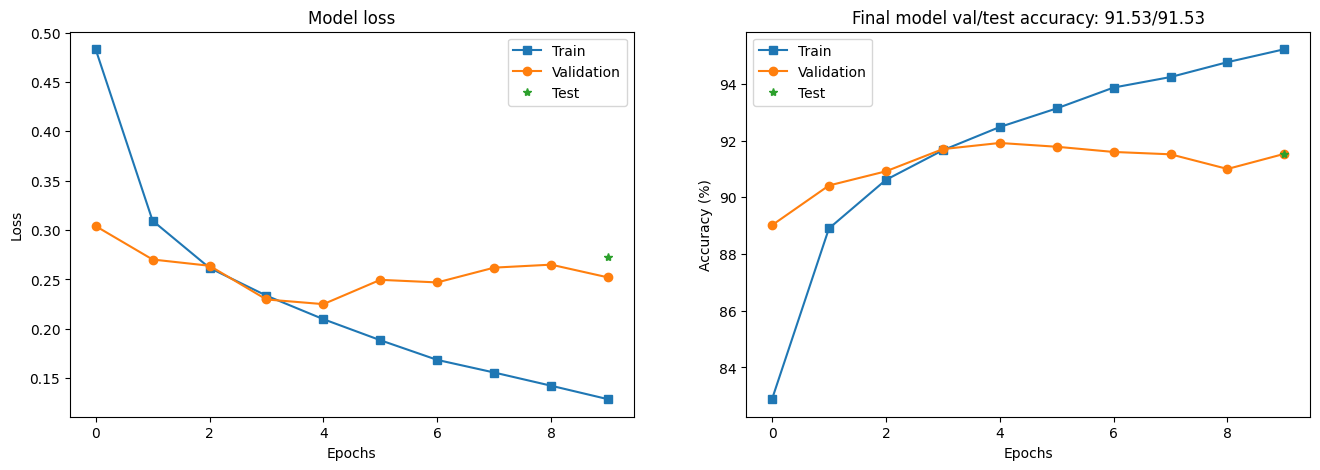

In [25]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses, 's-', label='Train')
ax[0].plot(val_losses, 'o-', label='Validation')
ax[0].plot(epochs_nr - 1, test_loss, '*', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(val_accuracies, 'o-', label='Validation')
ax[1].plot(epochs_nr - 1, test_accuracy, '*', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Final model val/test accuracy: %.2f/%.2f" %(val_accuracies[-1], test_accuracy))
ax[1].legend()

plt.show()

## Project 4: Psychometric functions in CNNs

In [26]:
images_nr = 1000
image_size = 30

images = torch.zeros(images_nr, 1, image_size, image_size)
labels = torch.zeros(images_nr, 1)

for i in range(images_nr):
    image = np.zeros((image_size, image_size))
    index = np.random.choice(np.arange(2, 28))

    if np.random.randn() > 0:
        image[index:index + 1, :] = 1
        labels[i, 0] = 0
    else:
        image[:, index:index + 1] = 1
        labels[i, 0] = 1

    images[i, :, :, :] = torch.Tensor(image).view(1, image_size, image_size)

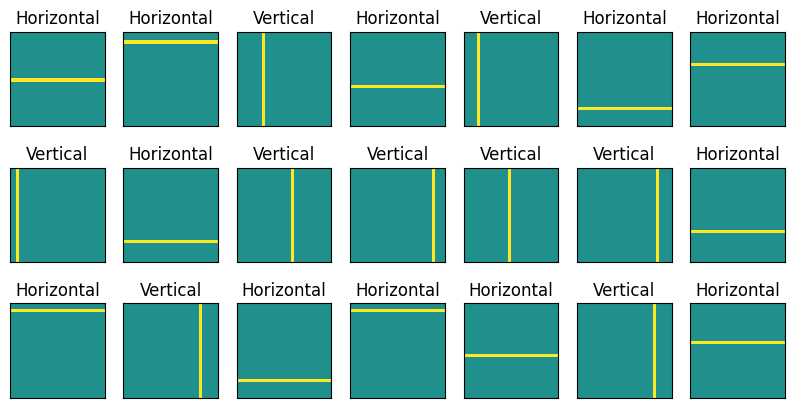

In [27]:
_, ax = plt.subplots(3, 7, figsize=(10, 5))

for i, ax in enumerate(ax.flatten()):
    index = np.random.randint(images_nr)
    image = np.squeeze(images[index, :, :])

    ax.imshow(image, vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Vertical' if labels[index] == 1 else 'Horizontal')

plt.show()

In [28]:
data_t = images.to(device)
labels_t = labels.to(device)

train_data, test_data, train_labels, test_labels = train_test_split(data_t, labels_t, test_size=.1)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [29]:
def create_model(print_toggle_param=False):
    class LineNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.conv1 = nn.Conv2d(1, 28, 3, 1, 1)
            self.bnorm1 = nn.BatchNorm2d(28)

            self.conv2 = nn.Conv2d(28, 56, 3, 1, 1)
            self.bnorm2 = nn.BatchNorm2d(56)
     
            self.conv3 = nn.Conv2d(56, 112, 3, 1, 1)
            self.bnorm3 = nn.BatchNorm2d(112)
            
            self.fc1 = nn.Linear(1008, 256)
            self.dropout = nn.Dropout(.6)
            self.output = nn.Linear(256, 1)
            
        def forward(self, x_param):
            if print_toggle_param: print(f"Input: {x_param.shape}")

            x_local = self.bnorm1(self.conv1(x_param))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"First CPR block: {x_local.shape}")
            
            x_local = self.bnorm2(self.conv2(x_local))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"Second CPR block: {x_local.shape}")
            
            x_local = self.bnorm3(self.conv3(x_local))
            x_local = F.max_pool2d(F.leaky_relu(x_local), 2)
            
            if print_toggle_param: print(f"Third CPR block: {x_local.shape}")
            
            x_local = torch.flatten(x_local, start_dim=1)
            
            if print_toggle_param: print(f"Vectorized: {x_local.shape}")
            
            x_local = F.leaky_relu(self.fc1(x_local))
            x_local = self.dropout(x_local)
            x_local = self.output(x_local)
            
            if print_toggle_param: print(f"Final output: {x_local.shape}")
            
            return x_local
      
    line_net_local = LineNet().to(device)
    loss_function_local = nn.BCEWithLogitsLoss()
    optimizer_local = torch.optim.Adam(line_net_local.parameters(), lr=.001)
    
    return line_net_local, loss_function_local, optimizer_local

In [30]:
def train_model(line_net_local, loss_function_local, optimizer_local):
    train_losses_local = []
    test_losses_local = []
    train_accuracies_local = []
    test_accuracies_local = []
     
    for epoch in range(epochs_nr):
        batch_losses = []
        batch_accuracies = []
         
        line_net_local.train()
         
        for X_local, y_local in train_loader:
            y_pred_local = line_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
               
            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()
            
            batch_losses.append(loss_local.item())
            batch_accuracies.append(torch.mean(((y_pred_local > 0) == y_local).float()).item())

        train_losses_local.append(np.mean(batch_losses))
        train_accuracies_local.append(100 * np.mean(batch_accuracies))

        line_net_local.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred_local = line_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
          
        test_losses_local.append(loss_local.item())
        test_accuracies_local.append(100 * torch.mean(((y_pred_local > 0) == y_local).float()).item())
     
    return train_accuracies_local, test_accuracies_local, train_losses_local, test_losses_local, line_net_local

In [31]:
line_net, loss_function, optimizer = create_model()
train_accuracies, test_accuracies, train_losses, test_losses, line_net = train_model(line_net, loss_function, optimizer)

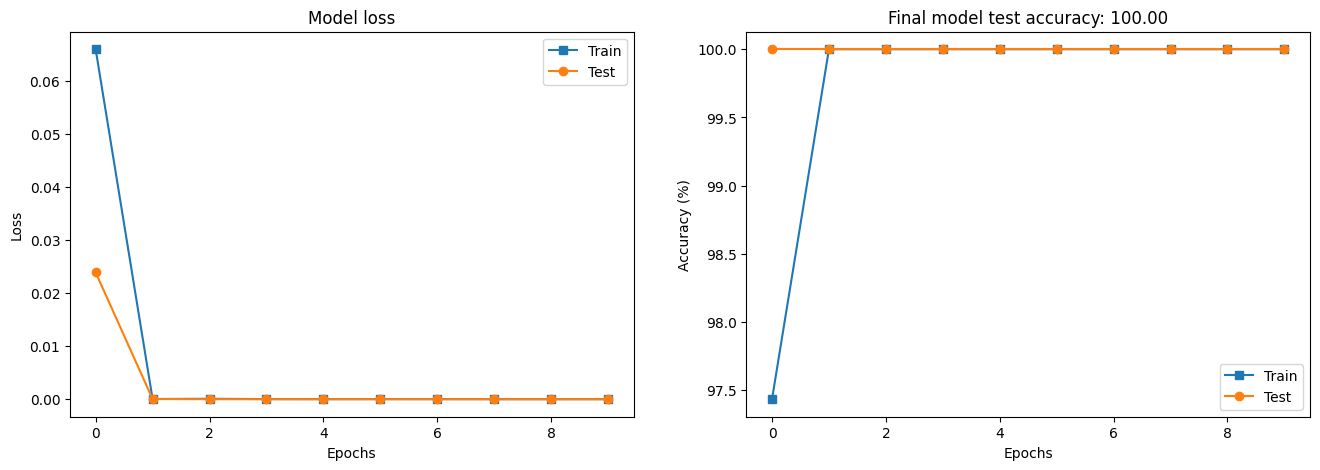

In [32]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses, 's-', label='Train')
ax[0].plot(test_losses, 'o-', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(test_accuracies, 'o-', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title(f"Final model test accuracy: {test_accuracies[-1]:.2f}")
ax[1].legend()

plt.show()

In [33]:
shallow_slopes = np.linspace(1, -1, 30)
slopes = np.concatenate([shallow_slopes, 1 / shallow_slopes])
images_with_slopes_nr = len(slopes)

images_with_slopes = torch.zeros(images_with_slopes_nr, 1, image_size, image_size)

center = (image_size - 1) / 2

for i, slope in enumerate(slopes):
    if abs(slope) <= 1:
        start_col, end_col = 0, image_size - 1
        start_row = center + slope * (start_col - center)
        end_row = center + slope * (end_col - center)
    else:
        start_row, end_row = 0, image_size - 1
        start_col = center + (start_row - center) / slope
        end_col = center + (end_row - center) / slope

    start_row, start_col, end_row, end_col = (
        min(max(int(round(value)), 0), image_size - 1)
        for value in (start_row, start_col, end_row, end_col)
    )

    row_indices, col_indices, intensities = line_aa(start_row, start_col, end_row, end_col)
    images_with_slopes[i, 0, row_indices, col_indices] = torch.Tensor(intensities)

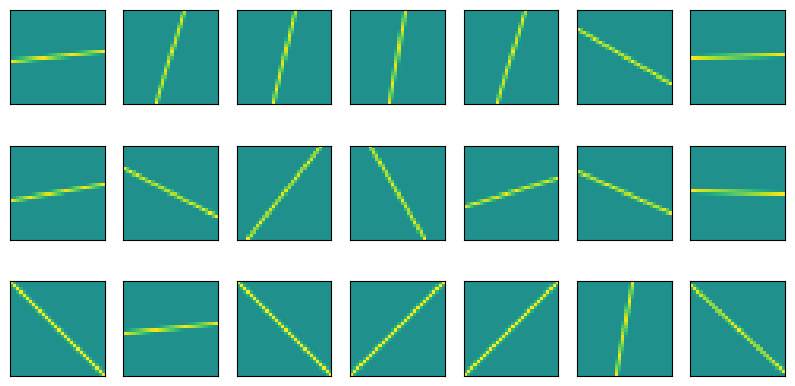

In [34]:
_, ax = plt.subplots(3, 7, figsize=(10, 5))

for i, ax in enumerate(ax.flatten()):
    index = np.random.randint(images_with_slopes_nr)
    image = np.squeeze(images_with_slopes[index, :, :])

    ax.imshow(image, vmin=-1, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [35]:
line_net.eval()

with torch.no_grad():
    y_pred = torch.sigmoid(line_net(images_with_slopes.to(device))).cpu()

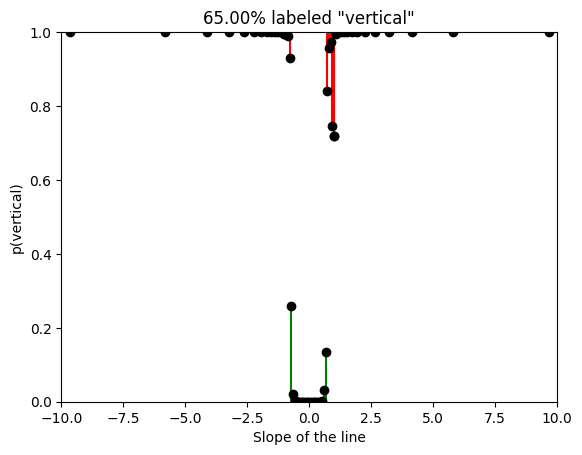

In [36]:
for i in range(len(slopes)):
    if y_pred[i] > .5:
        plt.plot([slopes[i], slopes[i]], [1, y_pred[i].item()], 'r')
    else:
        plt.plot([slopes[i], slopes[i]], [0, y_pred[i].item()], 'g')

plt.plot(slopes, y_pred, 'ko')
plt.xlabel("Slope of the line")
plt.ylabel("p(vertical)")
plt.title("%.2f%% labeled \"vertical\"" %torch.mean(100 * (y_pred > .5).float()).item())
plt.ylim([0, 1])
plt.xlim([-10, 10])

plt.show()

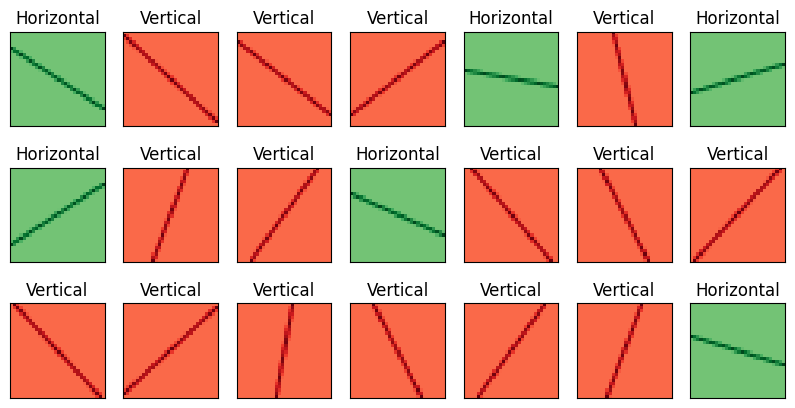

In [37]:
_, ax = plt.subplots(3, 7, figsize=(10, 5))

for i, ax in enumerate(ax.flatten()):
    index = np.random.randint(images_with_slopes_nr)
    image = np.squeeze(images_with_slopes[index, :, :])
    is_vertical = y_pred[index] > .5
    color = 'Reds' if is_vertical else 'Greens'
    title = 'Vertical' if is_vertical else 'Horizontal'

    ax.imshow(image, vmin=-1, vmax=1, cmap=color)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

plt.show()